In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from tqdm import tqdm

### Load Dataset

In [3]:
from in_memory_dataset import InMemoryTimeStepDataset
from torch_geometric.loader import DataLoader

train_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/train")
test_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/test")

batch_size = 4
num_workers = 2
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Found 5 sample files
Loaded the dataset with 250 samples
Found 1 sample files
Loaded the dataset with 49 samples


### Initialize Model

In [4]:
from models.vinay_mgn import MeshGraphNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_channels = 10
edge_channels = 4
num_messages = 8
latent_dim = 128

model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
_ = model.to(device)

### Initialize Trainer

In [5]:
from trainer import Trainer

lr = 3e-5
loss_type = "mse"

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
trainer = Trainer(model, optimizer, device, loss_type=loss_type)
torch.cuda.empty_cache()

/Users/ksteiner/miniforge3/envs/fenicsproject/lib/python3.10/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Train Loop

In [6]:
from tqdm.notebook import tqdm_notebook as tqdm
from preprocess_data import Stats
import json

print("Loading stats...")
with open("Results/train/stats/stats.json", "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])
dt = 0.08

total_epochs = 50

epoch_bar = tqdm(range(total_epochs), desc="Epochs")
for epoch in epoch_bar:
    for batch in tqdm(train_dataloader, desc="Batches", leave=False):
        # print("hey")
        trainer.train(batch)

    trainer.test(
        test_loader=test_dataloader,
        node_stats=node_stats,
        edge_stats=edge_stats,
        target_stats=target_stats,
        dt=dt,
    )
    trainer.epoch_end()
    trainer.save_model()
    epoch_bar.set_postfix(
        {"last_loss": f"{trainer.loss:.6f}, gen_loss: {trainer.gen_loss:.6f}"}
    )


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

ERROR:tornado.general:SEND Error: Host unreachable


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Show Training Progress

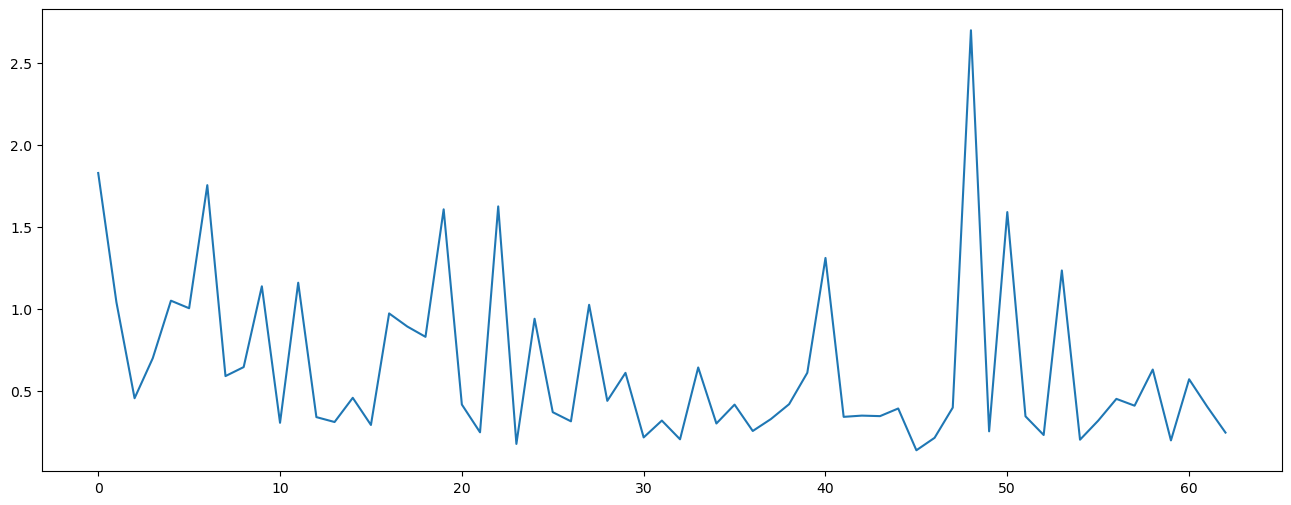

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.plot(trainer.train_history)
plt.show()

### Show animation

In [7]:
from rollout_utils import do_rollout


error_x, error_v, error_stress, true_rollout, pred_rollout = do_rollout(
    model=trainer.model,
    test_loader=test_dataloader,
    device=trainer.device,
    node_stats=node_stats,
    edge_stats=edge_stats,
    target_stats=target_stats,
    dt=dt,
)

In [ ]:
from make_gif import make_beam_comparison_gif


make_beam_comparison_gif(
    pred_rollout=pred_rollout,
    true_rollout=true_rollout,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif="beam_comparison.gif",
    fps=4,
)

Rendering frame 0/48
Rendering frame 1/48


/Users/ksteiner/github/BeamElastoDynamics/make_gif.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.close(fig)


Rendering frame 2/48
Rendering frame 3/48
Rendering frame 4/48
Rendering frame 5/48
Rendering frame 6/48
Rendering frame 7/48
Rendering frame 8/48
Rendering frame 9/48
Rendering frame 10/48
Rendering frame 11/48
Rendering frame 12/48
Rendering frame 13/48
Rendering frame 14/48
Rendering frame 15/48
Rendering frame 16/48
Rendering frame 17/48
Rendering frame 18/48
Rendering frame 19/48
Rendering frame 20/48
Rendering frame 21/48
Rendering frame 22/48
Rendering frame 23/48
Rendering frame 24/48
Rendering frame 25/48
Rendering frame 26/48
Rendering frame 27/48
Rendering frame 28/48
Rendering frame 29/48
Rendering frame 30/48
Rendering frame 31/48
Rendering frame 32/48
Rendering frame 33/48
Rendering frame 34/48
Rendering frame 35/48
Rendering frame 36/48
Rendering frame 37/48
Rendering frame 38/48
Rendering frame 39/48
Rendering frame 40/48
Rendering frame 41/48
Rendering frame 42/48
Rendering frame 43/48
Rendering frame 44/48
Rendering frame 45/48
Rendering frame 46/48
Rendering frame 47

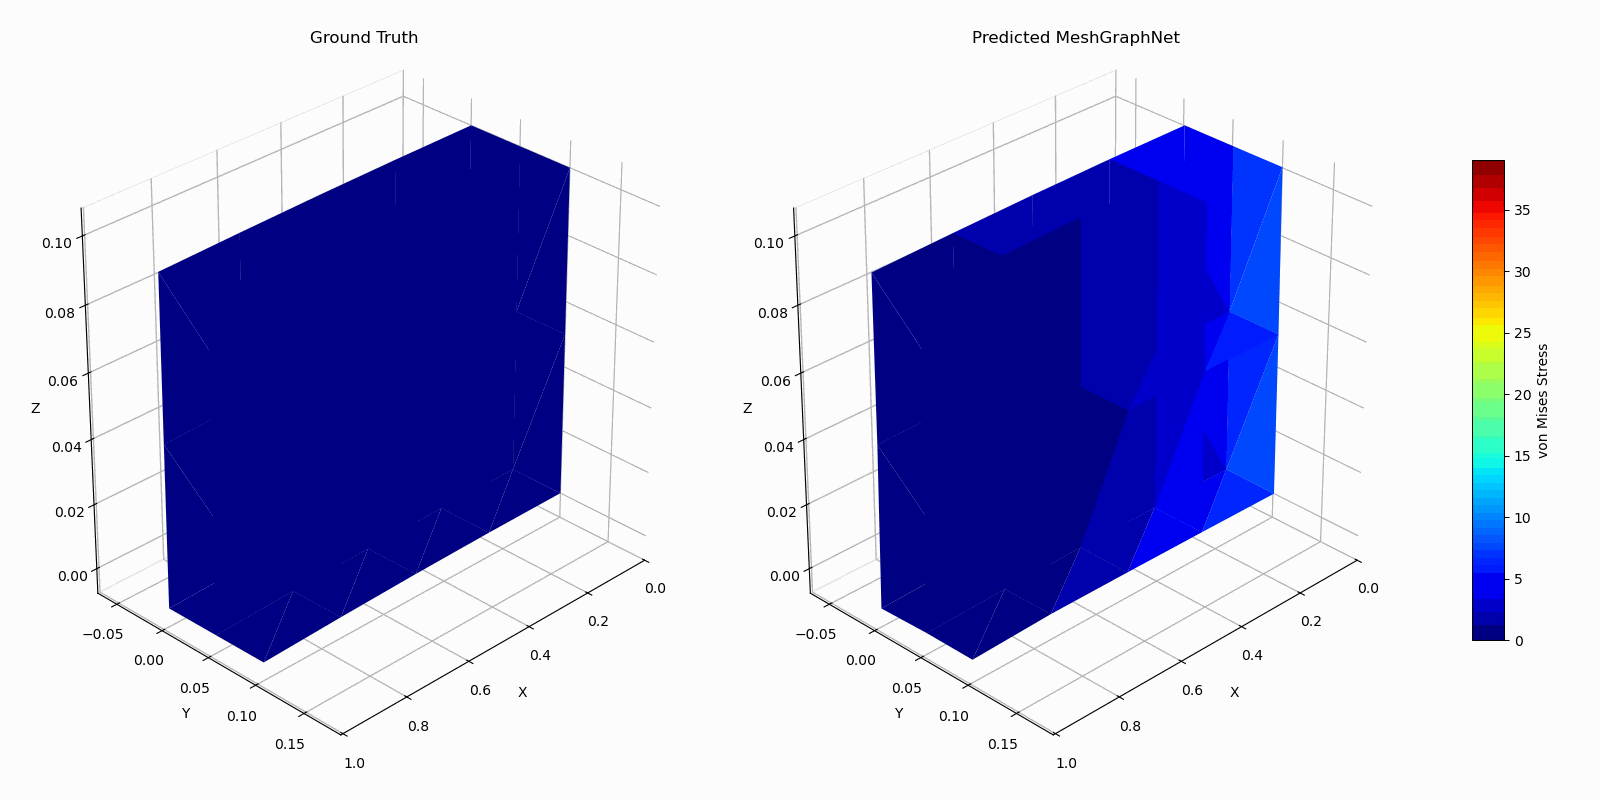

In [ ]:
from IPython.display import Image

Image(filename="beam_comparison.gif")